In [1]:
!pip install numpy
!pip install pandas
!pip install scipy
!pip install scikit-learn

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

In [12]:
import pandas as pd

# Load the datasets
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')
links = pd.read_csv('links.csv')
tags = pd.read_csv('tags.csv')

# Display the first few rows of each DataFrame
print("Ratings Data:")
print(ratings.head())

print("Movies Data:")
print(movies.head())

print("Links Data:")
print(links.head())

print("Tags Data:")
print(tags.head())

Ratings Data:
   userId  movieId  rating    timestamp
0       1        1     4.0  964982703.0
1       1        3     4.0  964981247.0
2       1        6     4.0  964982224.0
3       1       47     5.0  964983815.0
4       1       50     5.0  964982931.0
Movies Data:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
Links Data:
   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  11

In [13]:
# Merge ratings with movies to include movie titles
merged_df = pd.merge(ratings, movies, on='movieId')
print(merged_df.head())

   userId  movieId  rating     timestamp             title  \
0       1        1     4.0  9.649827e+08  Toy Story (1995)   
1       5        1     4.0  8.474350e+08  Toy Story (1995)   
2       7        1     4.5  1.106636e+09  Toy Story (1995)   
3      15        1     2.5  1.510578e+09  Toy Story (1995)   
4      17        1     4.5  1.305696e+09  Toy Story (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1  Adventure|Animation|Children|Comedy|Fantasy  
2  Adventure|Animation|Children|Comedy|Fantasy  
3  Adventure|Animation|Children|Comedy|Fantasy  
4  Adventure|Animation|Children|Comedy|Fantasy  


In [9]:
!pip install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 3.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp310-cp310-linux_x86_64.whl size=2357284 sha256=872f2383d071a7c799d4ac3f671512243f9b662280edb66dd3b7b288397b4d07
  Stored in directory: /root/.cache/pip/wheels/4b/3f/df/6acbf0a40397d9bf3ff97f582cc22fb9ce66adde75bc71fd54
Successfully built scikit-surprise


In [14]:
from surprise import Dataset, Reader

# Define a Reader object
reader = Reader(rating_scale=(0.5, 5.0))

# Load data into Surprise dataset format
data = Dataset.load_from_df(merged_df[['userId', 'movieId', 'rating']], reader)

In [15]:
from surprise.model_selection import train_test_split

# Split data into training and test sets
trainset, testset = train_test_split(data, test_size=0.2)

In [16]:
from surprise import SVD
from surprise import accuracy

# Use the SVD algorithm
model = SVD()
model.fit(trainset)

# Evaluate the model
predictions = model.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8896


0.8895822938192197

In [17]:
# Predict the rating for a specific user and movie
user_id = '1'  # Example user ID
movie_id = '1'  # Example movie ID

pred = model.predict(user_id, movie_id)
movie_title = movies[movies['movieId'] == int(movie_id)]['title'].values[0]

print(f"Predicted rating for user {user_id} on movie '{movie_title}': {pred.est}")

Predicted rating for user 1 on movie 'Toy Story (1995)': 3.5707198189572633


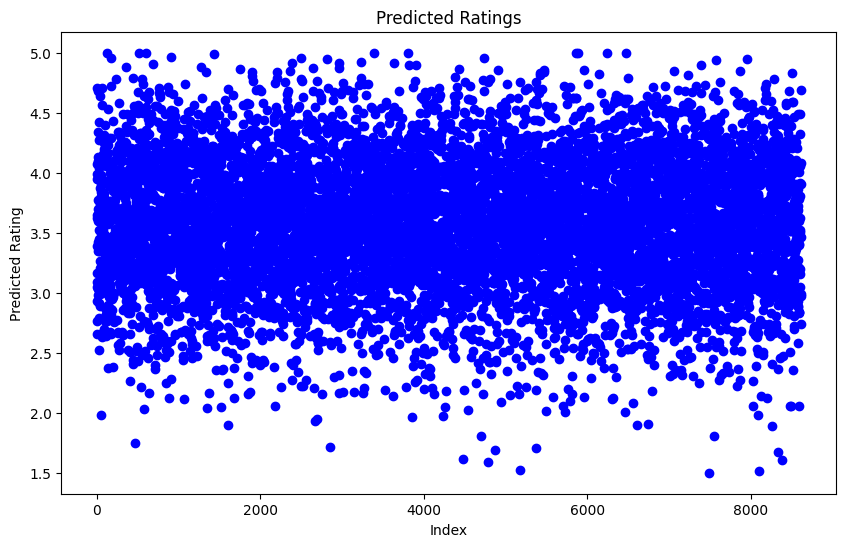

In [18]:
import matplotlib.pyplot as plt

# Example: Plot RMSE scores
plt.figure(figsize=(10, 6))
plt.plot(range(len(predictions)), [pred.est for pred in predictions], 'bo')
plt.title('Predicted Ratings')
plt.xlabel('Index')
plt.ylabel('Predicted Rating')
plt.show()